In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

In [2]:
# Constants
RISK_FREE_RATE = 0.042

INDICES = ["SPY", "IWM", "DIA"]
TICKERS = ["MU", "EQIX", "ETN", "AMD", "EL", "WDC", "ANET"]

PERIOD = "10y"

In [3]:
# Download ticker data
yfinance_data = yf.download(tickers=TICKERS+INDICES, period=PERIOD)['Close']

/tmp/ipykernel_87353/2046911079.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yfinance_data = yf.download(tickers=TICKERS+INDICES, period=PERIOD)['Close']
[*********************100%***********************]  10 of 10 completed


In [4]:
def calculate_returns(prices: pd.DataFrame) -> pd.DataFrame:
    daily_rets = prices.pct_change().dropna()
    return daily_rets

def calculate_vol(returns: pd.Series | pd.DataFrame) -> float:
    annualized_vol = np.sqrt(252) * returns.std()
    return annualized_vol

def calculate_beta(x: pd.Series, y: pd.Series) -> float:
    aligned = pd.concat([y, x], axis=1).dropna()
    if aligned.shape[0] < 2:
        return np.nan
    cov = np.cov(aligned.iloc[:,0], aligned.iloc[:,1], ddof=1)[0,1]
    var = np.var(aligned.iloc[:,1], ddof=1)
    return cov / var if var != 0 else np.nan


def weekly_drawdowns(prices: pd.Series, weeks: int = 52) -> tuple[float, float]:
    week = prices.resample('W').agg(['max', 'min']).dropna()
    week['drawdown'] = (week['min'] - week['max']) / week['max']
    last = week.tail(weeks)
    if last.empty:
        return np.nan, np.nan
    avg_dd = last['drawdown'].mean()
    max_dd = last['drawdown'].min()  # most negative value = worst drawdown
    return avg_dd, max_dd

def total_return(prices: pd.Series, years: int = 10) -> tuple[float, float]:
    end_date = prices.dropna().index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window = prices.loc[start_date:end_date].dropna()
    if window.empty or window.shape[0] < 2:
        return np.nan, np.nan
    tr = window.iloc[-1] / window.iloc[0] - 1.0
    ar = (1.0 + tr) ** (1/years) - 1.0
    return tr, ar

def risk_free_daily() -> pd.Series:
    rf = yf.download("^IRX", period=PERIOD)['Close'].dropna()
    rf = rf / 100
    # Convert annualized 13-week T-bill rate to daily equivalent
    rf_daily = (1 + rf) ** (1/252) - 1
    return rf_daily

def sharpe_ratio(returns: pd.Series, rf_daily: pd.Series) -> float:
    aligned = pd.concat([returns, rf_daily], axis=1).ffill()
    aligned.columns = ['ret', 'rf']
    aligned = aligned.dropna()
    ex = aligned['ret'] - aligned['rf']
    if aligned.empty or ex.std() == 0:
        return np.nan
    # Annualized Sharpe: mean excess return / std of excess return * sqrt(252)
    return ex.mean() / ex.std() * np.sqrt(252)

def tracking_error(portfolio: pd.Series, benchmark: pd.Series, years: int = 10) -> float:
    end_date = portfolio.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    aligned = pd.concat([portfolio, benchmark], axis=1)
    aligned = aligned[aligned.index >= start_date].dropna()
    if aligned.empty:
        return np.nan
    active = aligned.iloc[:,0] - aligned.iloc[:,1]
    return active.std() * np.sqrt(252)

In [5]:
prices = yfinance_data
returns = calculate_returns(yfinance_data)

asset_prices = prices[TICKERS]
asset_returns = returns[TICKERS]
etf_prices = prices[INDICES]
etf_returns = returns[INDICES]

In [6]:
w = np.repeat(1/len(TICKERS), len(TICKERS))
portfolio_returns = (asset_returns * w).sum(axis=1)
portfolio_prices = (1 + portfolio_returns).cumprod() * 100

In [10]:
end_date = asset_returns.index.max()
ret_3m = asset_returns[asset_returns.index >= end_date - pd.DateOffset(months=3)]
ret_12m = asset_returns[asset_returns.index >= end_date - pd.DateOffset(months=12)]
spy_12m = etf_returns['SPY'][etf_returns.index >= end_date - pd.DateOffset(months=12)]
iwm_12m = etf_returns['IWM'][etf_returns.index >= end_date - pd.DateOffset(months=12)]
dia_12m = etf_returns['DIA'][etf_returns.index >= end_date - pd.DateOffset(months=12)]

rows = []
for ticker in TICKERS:
    weight = 1/len(TICKERS)
    vol_3m = calculate_vol(ret_3m[ticker].dropna())
    beta_spy = calculate_beta(ret_12m[ticker], spy_12m)
    beta_iwm = calculate_beta(ret_12m[ticker], iwm_12m)
    beta_dia = calculate_beta(ret_12m[ticker], dia_12m)
    avg_dd, max_dd = weekly_drawdowns(asset_prices[ticker])
    tr10, ar10 = total_return(asset_prices[ticker])
    rows.append([ticker, weight, vol_3m, beta_spy, beta_iwm, beta_dia, avg_dd, max_dd, tr10, ar10])

asset_factors = pd.DataFrame(rows, columns=[
    'Ticker', 'Portfolio Weight', 'Annualized Volatility (3M)', 'SPY Beta', 'IWM Beta', 'DIA Beta',
    'Avg Weekly Drawdown', 'Max Weekly Drawdown', 'Total Return (10Y)', 'Annualized Total Return'
])

fmt1 = asset_factors.copy()
fmt1['Portfolio Weight']          = asset_factors['Portfolio Weight'].map('{:.1%}'.format)
fmt1['Annualized Volatility (3M)']= asset_factors['Annualized Volatility (3M)'].map('{:.2%}'.format)
fmt1['SPY Beta']                  = asset_factors['SPY Beta'].map('{:.2f}'.format)
fmt1['IWM Beta']                  = asset_factors['IWM Beta'].map('{:.2f}'.format)
fmt1['DIA Beta']                  = asset_factors['DIA Beta'].map('{:.2f}'.format)
fmt1['Avg Weekly Drawdown']       = asset_factors['Avg Weekly Drawdown'].map('{:.2%}'.format)
fmt1['Max Weekly Drawdown']       = asset_factors['Max Weekly Drawdown'].map('{:.2%}'.format)
fmt1['Total Return (10Y)']        = asset_factors['Total Return (10Y)'].map('{:.2%}'.format)
fmt1['Annualized Total Return']   = asset_factors['Annualized Total Return'].map('{:.2%}'.format)

print("Table 1: Asset Factors")
display(fmt1)

Table 1: Asset Factors


,Ticker,Portfolio Weight,Annualized Volatility (3M),SPY Beta,IWM Beta,DIA Beta,Avg Weekly Drawdown,Max Weekly Drawdown,Total Return (10Y),Annualized Total Return
0,MU,14.3%,70.18%,0.19,0.20,0.13,-8.20%,-27.04%,3427.15%,42.80%
1,EQIX,14.3%,29.54%,0.29,0.32,0.25,-3.10%,-17.76%,260.88%,13.69%
2,ETN,14.3%,33.25%,0.40,0.44,0.31,-4.19%,-13.15%,612.13%,21.69%
3,AMD,14.3%,63.84%,0.18,0.20,0.13,-7.00%,-21.83%,7165.83%,53.51%
4,EL,14.3%,60.96%,0.21,0.26,0.19,-5.69%,-23.02%,-18.40%,-2.01%
5,WDC,14.3%,86.09%,0.16,0.17,0.12,-7.47%,-26.90%,781.70%,24.32%
6,ANET,14.3%,56.06%,0.20,0.20,0.14,-6.68%,-19.70%,3170.68%,41.73%


In [11]:
rf_daily = risk_free_daily()
portfolio_sharpe = sharpe_ratio(portfolio_returns, rf_daily)
portfolio_volatility = calculate_vol(portfolio_returns.dropna())

rows = []
for etf in INDICES:
    etf_return = etf_returns[etf]
    correlation = portfolio_returns.corr(etf_return)
    aligned = pd.concat([portfolio_returns, etf_return], axis=1).dropna()
    cov = np.cov(aligned.T)[0, 1] if not aligned.empty else np.nan
    te = tracking_error(portfolio_returns, etf_return, years=10)
    etf_volatility = calculate_vol(etf_return.dropna())
    vol_spread = portfolio_volatility - etf_volatility
    rows.append([etf, correlation, cov, te, portfolio_sharpe, vol_spread])

portfolio_vs_etf = pd.DataFrame(rows, columns=[
    'ETF', 'Correlation', 'Covariance', 'Tracking Error', 'Sharpe Ratio', 'Annual Volatility Spread'
])

fmt2 = portfolio_vs_etf.copy()
fmt2['Correlation']             = portfolio_vs_etf['Correlation'].map('{:.4f}'.format)
fmt2['Covariance']              = portfolio_vs_etf['Covariance'].map('{:.6f}'.format)
fmt2['Tracking Error']          = portfolio_vs_etf['Tracking Error'].map('{:.2%}'.format)
fmt2['Sharpe Ratio']            = portfolio_vs_etf['Sharpe Ratio'].map('{:.2f}'.format)
fmt2['Annual Volatility Spread']= portfolio_vs_etf['Annual Volatility Spread'].map('{:.2%}'.format)

print("Table 2: Portfolio vs ETF Comparison")
display(fmt2)

/tmp/ipykernel_87353/2006249600.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rf = yf.download("^IRX", period=PERIOD)['Close'].dropna()
[*********************100%***********************]  1 of 1 completed

Table 2: Portfolio vs ETF Comparison


,ETF,Correlation,Covariance,Tracking Error,Sharpe Ratio,Annual Volatility Spread
0,SPY,0.8227,0.000172,17.84%,1.05,11.48%
1,IWM,0.7485,0.000200,19.51%,1.05,6.41%
2,DIA,0.7330,0.000149,20.39%,1.05,11.89%


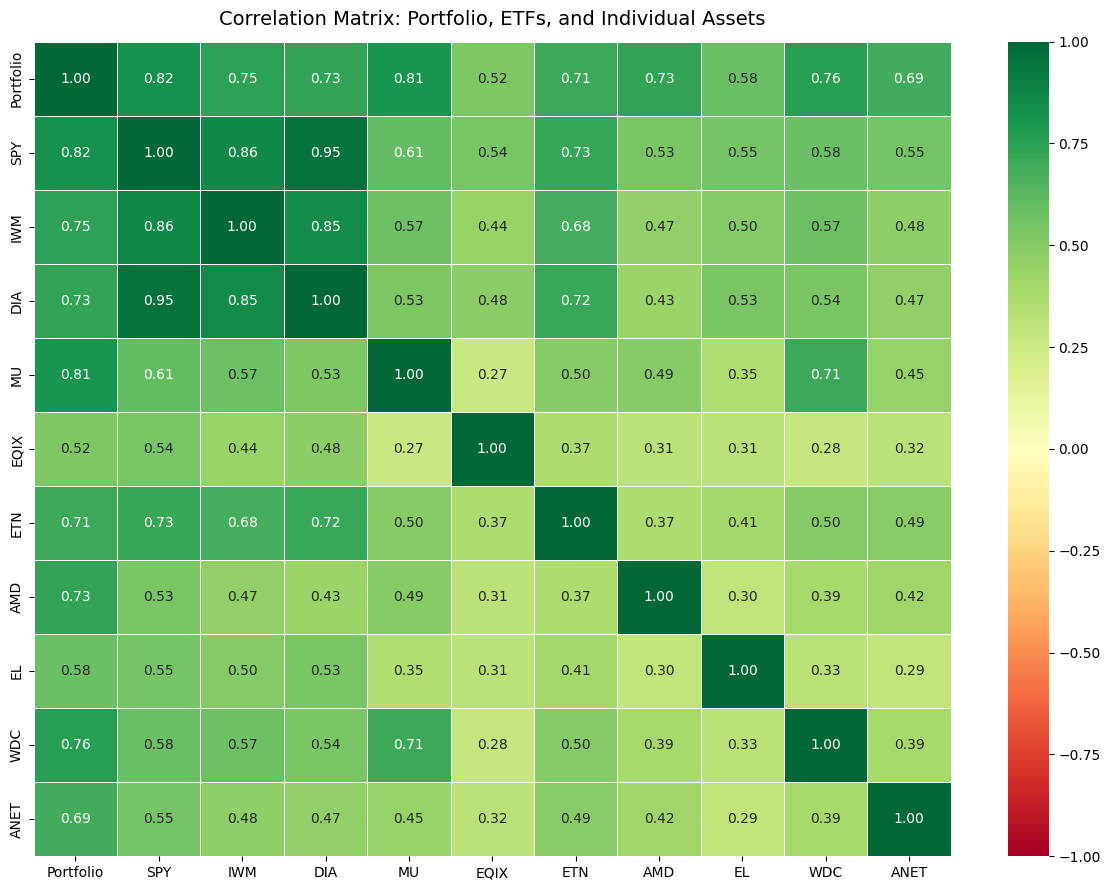

In [12]:
corr_df = pd.concat([portfolio_returns.rename('Portfolio'), etf_returns, asset_returns], axis=1).dropna().corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix: Portfolio, ETFs, and Individual Assets', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

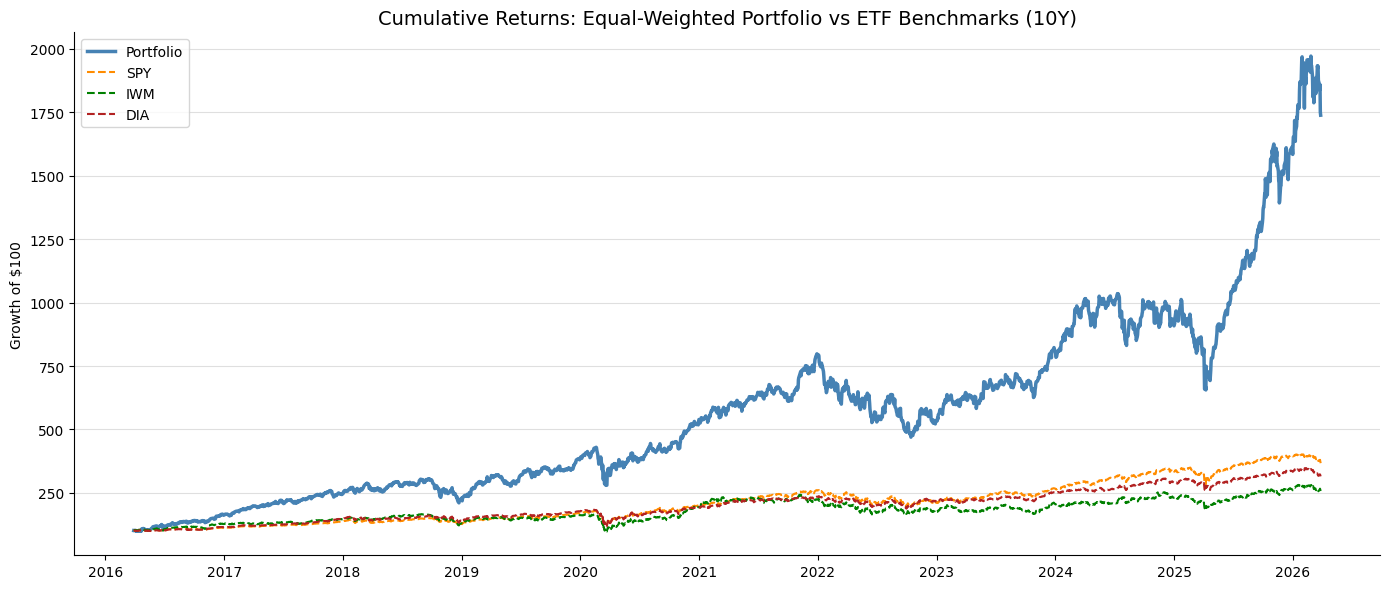

In [ ]:
all_returns = pd.concat([portfolio_returns.rename('Portfolio'), etf_returns], axis=1).dropna()
cumulative = (1 + all_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(14, 6))
styles = {'Portfolio': dict(linewidth=2.5, linestyle='-', color='steelblue'),
          'SPY':       dict(linewidth=1.5, linestyle='--', color='darkorange'),
          'IWM':       dict(linewidth=1.5, linestyle='--', color='green'),
          'DIA':       dict(linewidth=1.5, linestyle='--', color='firebrick')}

for col, kwargs in styles.items():
    ax.plot(cumulative.index, cumulative[col], label=col, **kwargs)

ax.set_title('Cumulative Returns: Equal-Weighted Portfolio vs ETF Benchmarks (10Y)', fontsize=14)
ax.set_ylabel('Growth of $100')
ax.set_xlabel('')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

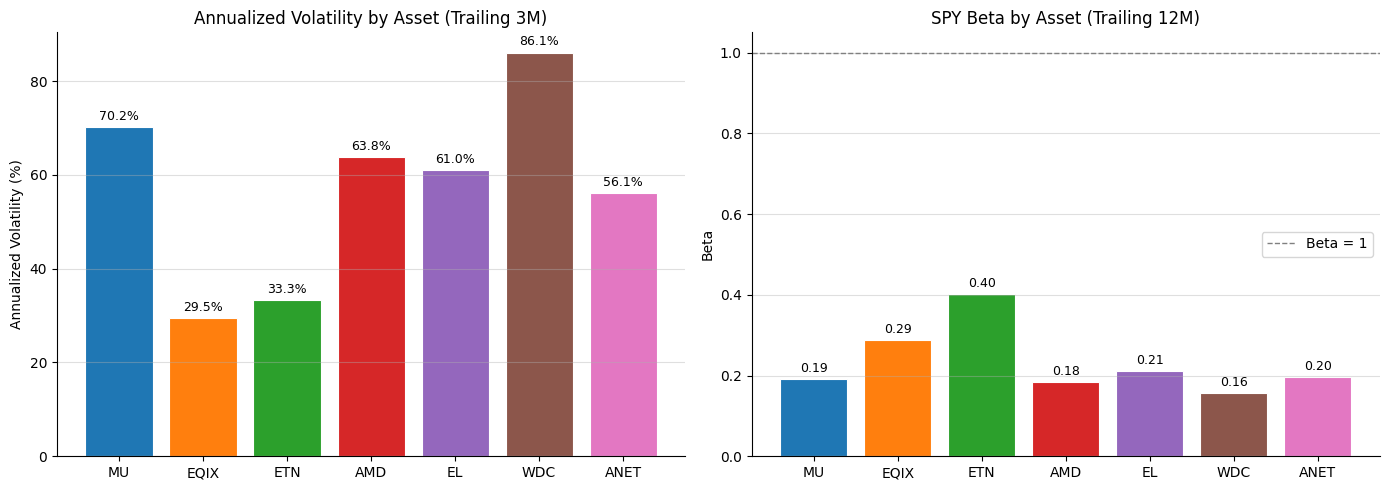

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tickers = asset_factors['Ticker']
vol = asset_factors['Annualized Volatility (3M)'] * 100
beta = asset_factors['SPY Beta']

palette = sns.color_palette('tab10', n_colors=len(tickers))

bars1 = ax1.bar(tickers, vol, color=palette, edgecolor='white', linewidth=0.8)
ax1.set_title('Annualized Volatility by Asset (Trailing 3M)', fontsize=12)
ax1.set_ylabel('Annualized Volatility (%)')
ax1.set_xlabel('')
ax1.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax1.grid(axis='y', alpha=0.4)
sns.despine(ax=ax1)

bars2 = ax2.bar(tickers, beta, color=palette, edgecolor='white', linewidth=0.8)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Beta = 1')
ax2.set_title('SPY Beta by Asset (Trailing 12M)', fontsize=12)
ax2.set_ylabel('Beta')
ax2.set_xlabel('')
ax2.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()